In [6]:
import scipy.io
import networkx as nx 
import bct 
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import nilearn
from nilearn import datasets, plotting, surface

# Preparation of dataset for use
num_subjects = 9

# definition of directory with dataset
dir_fmri_desikan = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/fmri_connect_desikan/'
dir_fmri_destrieux = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/fmri_connect_destrieux/'

dir_eeg_desikan = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/eeg_connect_desikan/'
dir_eeg_destrieux = '/strombolihome/fribeiro/Dataset/source_reconstructed_FC/eeg_connect_destrieux/'

# importing labels of atlas
mat_desikan = scipy.io.loadmat('/strombolihome/fribeiro/Dataset/source_reconstructed_FC/label_dsk.mat', squeeze_me=True)
labels_desikan = mat_desikan['label_dsk']
labels_desikan[67] = 'rINS' # small correction

mat_destrieux = scipy.io.loadmat('/strombolihome/fribeiro/Dataset/source_reconstructed_FC/label_dstrx.mat', squeeze_me=True)
labels_destrieux = mat_destrieux['label_dstrx']
labels_destrieux = labels_destrieux[12:160]
labels_destrieux[147] = 'rS_temporal_transverse' # small correction

In [7]:
# Script for creating graphs from fMRI and EEG connectivity data (coverting MATLAB matrices)

#1.Creation of average Graph 
def createAvGraph(file,data_type):
    
    # Load Matlab file with connectivity matrix for each time point - 3D matrix
    mat = scipy.io.loadmat(file)

    if data_type == 'fmri':
        conn_matrix = mat['connFMRI'].transpose() #connectivity fMRI matrix with numpy format
    elif data_type == 'eeg': #for now only for broad band TODO others !
        conn_matrix = mat['connEEGbroad'].transpose() #connectivity EEG matrix with numpy format
    elif data_type == 'eeg_alpha':
        conn_matrix = mat['connEEGalpha'].transpose()
    elif data_type == 'eeg_beta':
        conn_matrix = mat['connEEGbeta'].transpose()
    elif data_type == 'eeg_delta':
        conn_matrix = mat['connEEGdelta'].transpose()
    elif data_type == 'eeg_gamma':
        conn_matrix = mat['connEEGgamma'].transpose()
    elif data_type == 'eeg_theta':
        conn_matrix = mat['connEEGtheta'].transpose()
        
    t_points = conn_matrix.shape[0] # number of layers of multilayer matrix
    num_areas = conn_matrix.shape[1] #number of nodes of the graph
    
    # Get average connectivity matrix
    av_conn = np.zeros((num_areas,num_areas))
       
    for i in range(t_points):
        
        av_conn = av_conn + conn_matrix[i]
            
    av_conn = av_conn/t_points 
    
    G = nx.from_numpy_matrix(av_conn)
    
    return G

#2. Creation of array of graphs (equivalent to layers)
def createArrayGraph(file,data_type):
    
    # Load Matlab file with connectivity matrix for each time point - 3D matrix
    mat = scipy.io.loadmat(file)
    
    if data_type == 'fmri':
        conn_matrix = mat['connFMRI'].transpose() #connectivity fMRI matrix with numpy format
    elif data_type == 'eeg': #for now only for broad band TODO others !
        conn_matrix = mat['connEEGbroad'].transpose() #connectivity EEG matrix with numpy format
    elif data_type == 'eeg_alpha':
        conn_matrix = mat['connEEGalpha'].transpose()
    elif data_type == 'eeg_beta':
        conn_matrix = mat['connEEGbeta'].transpose()
    elif data_type == 'eeg_delta':
        conn_matrix = mat['connEEGdelta'].transpose()
    elif data_type == 'eeg_gamma':
        conn_matrix = mat['connEEGgamma'].transpose()
    elif data_type == 'eeg_theta':
        conn_matrix = mat['connEEGtheta'].transpose()

    t_points = conn_matrix.shape[0] # number of layers of multilayer matrix
    num_areas = conn_matrix.shape[1] #number of nodes of the graph
    
    array_graphs = np.empty(t_points, dtype=object) 
    
    for i in range(t_points):
        array_graphs[i] = nx.from_numpy_matrix(conn_matrix[i])
        
    return array_graphs

#concatenating all subjects
def createArrayGraphAllSubjects(file,type_data):
    
    array_graphs_all = []
    
    for f in range(0,len(file)):
        array_graphs = createArrayGraph(file[f], type_data)
        if f == 0:
            array_graphs_all = array_graphs
        else:
            array_graphs_all = np.concatenate([array_graphs_all, array_graphs])
    
    return array_graphs_all

#3. Threshold graph with given proportion
def thresholdGraph(G, threshold, type_data, type_threshold):
    
    if(type_data == 'fmri'):
        # get absolute value connectivity matrix
        conn_matrix = abs(nx.to_numpy_array(G))
    else:
        conn_matrix = nx.to_numpy_array(G)
     
    if (type_threshold == 'abs'):
        # to threshold graph keeping edges with weight equal or above certain value
        conn_new = bct.utils.threshold_absolute(conn_matrix, threshold, True)
    else:
        # to threshold graph keeping the top % of the edges 
        conn_new = bct.utils.threshold_proportional(conn_matrix, threshold, True)
        #add all weights equal to the minimal value kept
        min_val = np.min(conn_new[np.nonzero(conn_new)])
        index = np.transpose(np.where(conn_matrix == min_val))
        idx_i, idx_j = zip(*index)
        conn_new[idx_i, idx_j] = conn_matrix[idx_i, idx_j]
    
    #for the fMRI data we need to recover non-absolute values as Phase Coherence is between -1 and 1
    if(type_data == 'fmri'):
        
        ind_keep = np.transpose(np.nonzero(conn_new))
        conn_new = np.zeros((G.number_of_nodes(), G.number_of_nodes()))
        min_positive = 1 #to store minimum positive value kept of phase coherence
        max_negative = -1 #to store maximum negative value kept of phase coherence
        
        idx_i, idx_j = zip(*ind_keep)

        conn_new[idx_i, idx_j] = nx.to_numpy_array(G)[idx_i, idx_j]
        
        # remove self loops
        np.fill_diagonal(conn_new, 0)
        
        #In case we want the minimum value of connectivity kept
        
        #for ind in ind_keep:
        #    #print(nx.to_numpy_array(G)[ind[0],ind[1]])
        #    conn_new[ind[0],ind[1]] = nx.to_numpy_array(G)[ind[0],ind[1]]
        #    #print(conn_new[ind[0],ind[1]])
        #    if nx.to_numpy_array(G)[ind[0],ind[1]] > 0 and nx.to_numpy_array(G)[ind[0],ind[1]] < min_positive:
        #        min_positive = nx.to_numpy_array(G)[ind[0],ind[1]]
        #    elif nx.to_numpy_array(G)[ind[0],ind[1]] < 0 and nx.to_numpy_array(G)[ind[0],ind[1]] > max_negative:
        #        max_negative = nx.to_numpy_array(G)[ind[0],ind[1]]
        
        G_new = nx.from_numpy_matrix(conn_new)
        
        return [G_new, conn_new, min_positive, max_negative]
    
    else:
        min_coh = np.amin(conn_new) #to store minimum value kept of imaginary part of coherency
        G_new = nx.from_numpy_matrix(conn_new)
        
        return [G_new, conn_new, min_coh]  

#4. Get the components of the graph after thresholding
def getThresholdComponents(G,threshold,data, type_threshold):
    
    if data == 'fmri':
        G_new, conn_matrix, min_pos, max_neg = thresholdGraph(G, threshold, data, type_threshold)
    else:
        G_new, conn_matrix, min_coh = thresholdGraph(G, threshold, data, type_threshold)
    
    graph_components = sorted(nx.connected_components(G_new), key=len, reverse=True)
    
    return graph_components


In [8]:
from community import community_louvain
#import community as community_louvain
import sys
sys.path.append('python-modularity-maximization')


def findCommunitiesLouvain(file):

    G = nx.from_numpy_matrix(file)
    #first compute the best partition
    part = community_louvain.best_partition(G) #returns dictionary assign a community (integer) to each node
    mod = community_louvain.modularity(part, G) #compute modularity
    print("Modularity of the network:", mod)
    #print(part)

    values = [part.get(node) for node in G.nodes()]

    number_communities = max(values)+1
    print("Number of communities:", number_communities)
    count_communities = np.zeros((number_communities,), dtype=int)
    content_communities = []
    for n in range(number_communities):
        content_communities.append([])
    for key,value in part.items():
        count_communities[value] += 1
        content_communities[value].append(key)
    
    print(count_communities)
    #print(content_communities)
    
    return content_communities

In [45]:
print("NMI")
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold11.0_fmri_dsk.npy')
    communities_fmri = findCommunitiesLouvain(file)
    print(communities_fmri[1])

print("Jacc")
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/Jacc_giant_component/time_points/subj0' + str(s) + '/Jaccard_Index_giant_component_threshold11.0_fmri_dsk.npy')
    communities_fmri = findCommunitiesLouvain(file)
    print(communities_fmri[1])

NMI
Modularity of the network: 0.2815359107352505
Number of communities: 2
[264 136]
[6, 11, 13, 15, 16, 17, 18, 19, 31, 33, 37, 39, 41, 42, 43, 45, 46, 49, 50, 51, 54, 56, 58, 59, 60, 62, 63, 64, 65, 66, 69, 70, 71, 73, 75, 76, 79, 81, 83, 84, 87, 89, 90, 91, 94, 98, 111, 112, 115, 116, 120, 121, 122, 123, 128, 141, 144, 146, 148, 149, 151, 157, 158, 164, 165, 166, 167, 170, 172, 173, 177, 180, 181, 183, 184, 186, 190, 197, 198, 211, 213, 214, 215, 217, 220, 222, 231, 232, 239, 243, 244, 249, 252, 253, 254, 257, 262, 263, 265, 266, 267, 268, 269, 270, 287, 288, 290, 292, 293, 303, 308, 310, 318, 320, 343, 347, 348, 351, 353, 358, 359, 361, 364, 365, 366, 369, 370, 371, 373, 381, 382, 383, 386, 388, 389, 398]
Modularity of the network: 0.40790183464495966
Number of communities: 2
[320 128]
[3, 6, 12, 18, 20, 25, 28, 29, 30, 38, 40, 41, 42, 44, 46, 47, 49, 50, 55, 56, 68, 70, 73, 83, 84, 85, 86, 88, 89, 94, 95, 96, 98, 99, 110, 114, 115, 116, 118, 120, 121, 126, 128, 129, 131, 133, 134,

Modularity of the network: 0.015259443061650614
Number of communities: 7
[202 202  13  23   4   3   1]
[3, 6, 7, 8, 11, 12, 14, 15, 18, 19, 20, 25, 28, 29, 30, 32, 33, 34, 37, 38, 40, 41, 42, 44, 46, 47, 49, 50, 53, 55, 56, 64, 68, 69, 70, 72, 73, 75, 78, 83, 84, 85, 86, 88, 89, 91, 94, 95, 96, 98, 99, 107, 110, 112, 114, 115, 116, 118, 120, 121, 126, 127, 128, 129, 131, 133, 134, 136, 139, 140, 141, 142, 143, 145, 149, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 166, 167, 169, 170, 171, 172, 174, 175, 177, 178, 179, 180, 181, 185, 187, 188, 190, 191, 192, 193, 195, 196, 201, 202, 211, 212, 213, 214, 221, 227, 240, 243, 245, 246, 247, 250, 254, 255, 256, 257, 258, 259, 260, 261, 262, 266, 268, 269, 271, 276, 278, 280, 282, 283, 284, 296, 298, 307, 308, 309, 313, 314, 315, 316, 317, 324, 334, 336, 338, 340, 342, 346, 348, 349, 350, 352, 353, 354, 355, 357, 358, 359, 360, 361, 363, 369, 370, 371, 374, 380, 381, 382, 384, 392, 394, 395, 396, 401, 405, 406, 407, 414, 418, 423, 4

In [46]:
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold7.000000000000001_eeg_alpha_dsk.npy')
    communities_eeg_alpha = findCommunitiesLouvain(file)
    print(communities_eeg_alpha)

print("Jacc")
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/Jacc_giant_component/time_points/subj0' + str(s) + '/Jaccard_Index_giant_component_threshold7.000000000000001_eeg_alpha_dsk.npy')
    communities_eeg_alpha = findCommunitiesLouvain(file)
    print(communities_eeg_alpha)

Modularity of the network: 0.11143783963881027
Number of communities: 10
[38 73 84 44 26 42 31 59  2  1]
[[0, 2, 11, 12, 16, 17, 28, 37, 38, 49, 59, 72, 77, 85, 98, 111, 113, 124, 138, 141, 161, 165, 174, 193, 207, 222, 232, 247, 257, 272, 273, 288, 299, 316, 326, 328, 375, 378], [1, 3, 15, 21, 22, 23, 24, 25, 34, 45, 53, 58, 62, 80, 82, 88, 89, 97, 103, 107, 116, 128, 129, 142, 143, 148, 159, 173, 197, 199, 210, 211, 212, 214, 217, 219, 239, 243, 261, 266, 268, 269, 270, 275, 281, 292, 293, 298, 308, 310, 315, 317, 327, 337, 341, 342, 348, 349, 364, 370, 371, 372, 373, 376, 381, 382, 384, 388, 389, 391, 392, 393, 399], [4, 10, 14, 18, 26, 33, 35, 40, 41, 42, 43, 44, 47, 48, 63, 67, 68, 73, 83, 84, 92, 95, 96, 104, 105, 108, 112, 125, 127, 130, 140, 145, 151, 160, 162, 163, 164, 166, 169, 171, 172, 180, 189, 191, 196, 200, 205, 218, 229, 236, 242, 252, 259, 260, 262, 265, 280, 285, 286, 290, 294, 305, 320, 322, 330, 333, 334, 338, 344, 345, 346, 351, 354, 356, 357, 358, 361, 368, 383, 

Modularity of the network: 0.0836672091708502
Number of communities: 6
[ 70  80  88  78 102   2]
[[0, 1, 13, 19, 23, 35, 36, 37, 38, 39, 46, 48, 72, 74, 75, 86, 87, 95, 96, 97, 117, 122, 128, 134, 135, 141, 143, 146, 150, 152, 156, 164, 174, 175, 178, 189, 197, 201, 218, 227, 240, 241, 267, 268, 272, 273, 279, 289, 292, 327, 328, 329, 331, 339, 342, 344, 345, 353, 354, 369, 371, 374, 376, 377, 378, 383, 384, 388, 395, 409], [2, 3, 5, 6, 9, 14, 17, 22, 29, 34, 54, 63, 64, 69, 71, 79, 83, 92, 93, 100, 106, 107, 110, 123, 130, 132, 145, 161, 163, 165, 171, 172, 183, 184, 199, 205, 208, 210, 217, 219, 222, 234, 243, 244, 246, 253, 254, 255, 259, 260, 262, 280, 281, 283, 284, 288, 294, 296, 307, 308, 309, 311, 312, 316, 318, 336, 337, 341, 350, 360, 366, 380, 382, 389, 392, 393, 407, 408, 415, 416], [4, 10, 12, 15, 26, 28, 31, 42, 43, 49, 65, 67, 68, 82, 85, 94, 98, 99, 114, 116, 121, 125, 126, 127, 131, 144, 149, 158, 162, 167, 168, 173, 181, 182, 185, 186, 193, 194, 200, 203, 204, 206, 20

Modularity of the network: 0.008461896564525248
Number of communities: 6
[ 21 215  93 109   7   3]
[[0, 40, 43, 51, 60, 78, 89, 97, 109, 153, 165, 208, 226, 239, 268, 277, 380, 384, 392, 410, 442], [1, 2, 5, 6, 9, 11, 12, 14, 16, 17, 20, 21, 24, 25, 26, 27, 29, 34, 41, 42, 45, 47, 48, 49, 50, 54, 58, 63, 64, 72, 74, 77, 82, 83, 84, 87, 88, 90, 91, 92, 93, 94, 95, 98, 105, 108, 112, 113, 115, 117, 120, 121, 122, 123, 124, 126, 128, 131, 132, 133, 134, 135, 137, 138, 139, 140, 143, 144, 147, 148, 149, 150, 151, 152, 155, 156, 157, 158, 159, 160, 161, 162, 167, 168, 169, 170, 171, 172, 174, 176, 177, 178, 179, 180, 182, 183, 184, 185, 187, 189, 192, 193, 194, 197, 198, 199, 200, 201, 203, 204, 205, 207, 209, 211, 212, 213, 214, 216, 217, 219, 221, 223, 224, 225, 227, 228, 229, 230, 233, 240, 245, 247, 248, 252, 253, 254, 256, 257, 259, 266, 274, 275, 276, 281, 284, 285, 286, 288, 289, 292, 293, 294, 296, 297, 298, 299, 300, 301, 302, 303, 304, 310, 314, 315, 316, 321, 323, 324, 325, 326, 

Modularity of the network: 0.007192108052553166
Number of communities: 7
[ 38 186  33  37  12  89  12]
[[0, 21, 25, 27, 28, 30, 48, 69, 72, 76, 77, 88, 90, 94, 99, 100, 103, 105, 109, 138, 148, 193, 215, 237, 238, 248, 271, 272, 274, 275, 279, 288, 294, 338, 367, 376, 382, 391], [1, 2, 3, 4, 8, 9, 10, 12, 15, 16, 17, 18, 23, 24, 26, 29, 32, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 47, 56, 57, 61, 64, 65, 68, 71, 75, 80, 81, 82, 83, 85, 89, 97, 101, 102, 104, 106, 111, 112, 113, 115, 119, 123, 124, 125, 126, 129, 130, 132, 133, 134, 135, 136, 137, 139, 143, 146, 147, 149, 152, 153, 154, 155, 156, 159, 160, 163, 167, 169, 170, 171, 173, 174, 177, 178, 181, 182, 188, 190, 191, 192, 194, 197, 198, 199, 200, 201, 202, 204, 205, 208, 209, 210, 219, 221, 225, 226, 227, 228, 233, 234, 235, 241, 242, 243, 244, 247, 252, 253, 254, 255, 259, 260, 261, 262, 265, 266, 268, 278, 280, 282, 285, 289, 290, 292, 296, 297, 298, 299, 304, 305, 306, 310, 312, 316, 317, 321, 322, 324, 327, 328, 329, 330, 331

In [13]:
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold6.1_eeg_beta_dsk.npy')
    communities_eeg_beta = findCommunitiesLouvain(file)
    print(communities_eeg_beta)

Modularity of the network: 0.12255083452245667
Number of communities: 8
[70 64 17 62 79 52 52  4]
[[0, 1, 3, 5, 7, 24, 30, 34, 35, 51, 61, 67, 71, 73, 75, 77, 83, 91, 103, 109, 111, 125, 126, 133, 135, 146, 149, 156, 166, 168, 174, 180, 188, 193, 194, 199, 206, 212, 240, 255, 257, 265, 271, 275, 280, 285, 291, 293, 294, 298, 300, 303, 307, 314, 315, 320, 325, 326, 336, 337, 343, 351, 354, 358, 366, 376, 382, 389, 391, 398], [2, 12, 13, 27, 36, 37, 44, 53, 54, 60, 70, 86, 88, 95, 105, 129, 131, 138, 139, 143, 157, 162, 164, 181, 183, 186, 208, 209, 214, 215, 219, 220, 222, 223, 224, 226, 231, 232, 236, 249, 250, 256, 258, 261, 264, 278, 279, 281, 295, 308, 313, 317, 322, 328, 329, 330, 334, 350, 356, 369, 387, 388, 394, 397], [4, 39, 81, 92, 113, 119, 132, 191, 266, 289, 306, 321, 332, 340, 360, 386, 392], [6, 8, 9, 10, 11, 14, 23, 26, 31, 41, 45, 52, 57, 63, 66, 68, 72, 78, 100, 112, 124, 127, 141, 151, 159, 165, 176, 178, 185, 190, 197, 211, 227, 230, 233, 238, 246, 253, 254, 272, 273

Modularity of the network: 0.11417075825316608
Number of communities: 8
[46 50 59 45 71 79 67  3]
[[0, 3, 5, 25, 27, 33, 50, 66, 80, 86, 89, 93, 94, 120, 134, 148, 158, 159, 160, 170, 172, 195, 198, 203, 206, 226, 248, 278, 285, 286, 293, 350, 352, 355, 356, 358, 365, 373, 374, 377, 379, 386, 407, 408, 414, 418], [1, 24, 39, 57, 58, 59, 65, 68, 92, 100, 101, 103, 105, 125, 132, 137, 147, 162, 166, 167, 176, 177, 185, 201, 205, 208, 214, 222, 228, 238, 252, 253, 260, 261, 262, 268, 277, 281, 299, 302, 329, 341, 342, 348, 360, 364, 369, 403, 406, 410], [2, 10, 12, 34, 35, 36, 47, 48, 51, 52, 55, 62, 71, 72, 73, 74, 76, 102, 113, 114, 116, 118, 119, 124, 144, 154, 155, 156, 157, 161, 165, 168, 180, 186, 188, 204, 212, 221, 236, 243, 247, 249, 255, 264, 280, 288, 291, 322, 339, 343, 347, 353, 363, 376, 392, 395, 400, 402, 411], [4, 8, 23, 28, 37, 44, 63, 96, 111, 117, 121, 128, 138, 143, 163, 178, 184, 189, 191, 192, 200, 209, 210, 219, 225, 229, 235, 237, 246, 251, 256, 289, 290, 295, 298

In [14]:
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold7.5_eeg_delta_dsk.npy')
    communities_eeg_delta = findCommunitiesLouvain(file)
    print(communities_eeg_delta)

Modularity of the network: 0.10687453144186847
Number of communities: 9
[83 32 58 31 50 47 44 53  2]
[[0, 1, 4, 7, 11, 21, 22, 31, 34, 45, 46, 47, 52, 70, 73, 81, 82, 85, 87, 88, 91, 92, 97, 105, 106, 114, 119, 130, 135, 139, 144, 146, 147, 150, 156, 157, 165, 166, 172, 174, 176, 177, 188, 197, 200, 211, 221, 227, 228, 232, 237, 238, 240, 243, 244, 259, 260, 261, 265, 272, 274, 275, 301, 305, 312, 314, 319, 320, 322, 324, 333, 338, 341, 344, 348, 350, 359, 365, 381, 382, 385, 394, 398], [2, 3, 12, 16, 57, 61, 84, 103, 116, 118, 124, 133, 134, 140, 145, 155, 173, 206, 242, 248, 279, 280, 287, 291, 300, 303, 321, 345, 355, 368, 375, 386], [5, 6, 8, 10, 18, 35, 36, 41, 42, 56, 66, 67, 72, 77, 86, 89, 95, 99, 107, 108, 117, 121, 127, 128, 137, 167, 178, 180, 183, 184, 191, 192, 205, 214, 216, 220, 222, 223, 235, 246, 269, 270, 273, 290, 292, 293, 294, 296, 299, 313, 337, 346, 362, 366, 371, 376, 377, 393], [9, 29, 50, 60, 80, 120, 132, 151, 168, 195, 196, 202, 203, 210, 212, 236, 249, 254,

Modularity of the network: 0.13669059164661937
Number of communities: 11
[42 65 48 51 30 30 50 43 25 33  3]
[[0, 14, 17, 35, 57, 63, 70, 92, 112, 122, 124, 144, 156, 172, 174, 186, 197, 201, 221, 233, 237, 246, 256, 279, 280, 286, 296, 299, 301, 308, 311, 334, 335, 348, 359, 380, 389, 390, 393, 404, 408, 418], [1, 2, 28, 32, 37, 45, 48, 61, 65, 72, 74, 76, 78, 80, 82, 83, 84, 101, 103, 109, 139, 154, 155, 158, 162, 163, 168, 179, 181, 183, 185, 187, 205, 206, 209, 210, 213, 214, 222, 232, 239, 245, 258, 261, 263, 281, 285, 294, 297, 298, 318, 324, 332, 336, 338, 347, 349, 364, 370, 371, 381, 399, 402, 416, 419], [3, 10, 24, 36, 41, 44, 46, 47, 54, 60, 67, 79, 81, 89, 95, 96, 105, 106, 135, 147, 148, 151, 152, 165, 173, 175, 184, 192, 194, 199, 243, 244, 249, 257, 276, 292, 295, 300, 302, 322, 325, 328, 344, 345, 358, 367, 398, 413], [4, 13, 19, 38, 102, 110, 113, 115, 116, 126, 141, 171, 180, 189, 204, 207, 208, 219, 228, 229, 235, 250, 252, 262, 264, 265, 267, 273, 284, 303, 304, 310,

In [15]:
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold7.000000000000001_eeg_gamma_dsk.npy')
    communities_eeg_gamma = findCommunitiesLouvain(file)
    print(communities_eeg_gamma)

Modularity of the network: 0.15620998059237678
Number of communities: 7
[65 98 56 74 53 48  6]
[[0, 12, 18, 20, 43, 58, 60, 61, 62, 75, 80, 81, 83, 90, 95, 103, 104, 105, 108, 112, 143, 146, 151, 160, 172, 177, 184, 189, 194, 200, 201, 206, 216, 217, 227, 233, 236, 243, 252, 253, 257, 262, 270, 272, 288, 291, 293, 303, 304, 319, 325, 334, 350, 352, 353, 361, 369, 376, 377, 380, 382, 388, 393, 397, 398], [1, 2, 3, 4, 5, 8, 9, 13, 14, 19, 21, 26, 36, 37, 40, 42, 46, 49, 51, 54, 55, 67, 68, 69, 70, 72, 77, 79, 84, 85, 88, 89, 92, 110, 119, 121, 124, 125, 128, 130, 134, 136, 138, 140, 142, 152, 154, 158, 164, 166, 167, 176, 178, 191, 197, 199, 214, 215, 219, 222, 237, 240, 244, 249, 255, 259, 260, 261, 268, 271, 275, 276, 281, 286, 287, 295, 298, 311, 313, 314, 318, 329, 330, 335, 344, 346, 347, 348, 355, 358, 363, 364, 365, 383, 384, 385, 389, 391], [6, 10, 25, 35, 45, 48, 59, 71, 74, 78, 82, 98, 107, 111, 126, 127, 129, 137, 157, 159, 162, 171, 173, 174, 186, 188, 192, 195, 196, 208, 209

Modularity of the network: 0.14557690108626745
Number of communities: 7
[92 85 78 59  3 98  5]
[[0, 1, 2, 10, 12, 13, 17, 18, 20, 25, 32, 33, 36, 39, 42, 43, 45, 46, 54, 64, 66, 68, 76, 77, 80, 82, 83, 100, 101, 105, 117, 119, 121, 124, 127, 132, 140, 141, 143, 146, 149, 161, 169, 174, 178, 181, 182, 195, 205, 213, 222, 232, 233, 238, 247, 248, 252, 256, 257, 265, 269, 271, 279, 284, 286, 288, 293, 300, 316, 324, 327, 334, 335, 338, 342, 354, 357, 358, 367, 373, 381, 385, 387, 396, 398, 400, 402, 403, 405, 410, 412, 416], [3, 7, 9, 15, 28, 30, 31, 53, 57, 58, 60, 63, 67, 69, 73, 75, 87, 89, 91, 94, 98, 103, 108, 114, 120, 125, 128, 129, 134, 136, 138, 147, 148, 150, 151, 152, 153, 160, 163, 172, 173, 175, 176, 180, 185, 193, 199, 202, 203, 207, 215, 220, 223, 234, 245, 253, 255, 266, 268, 272, 274, 278, 289, 290, 298, 299, 304, 314, 318, 325, 330, 341, 346, 347, 350, 360, 362, 369, 372, 384, 388, 395, 404, 411, 414], [4, 5, 23, 27, 34, 49, 50, 52, 59, 65, 71, 72, 79, 84, 85, 86, 88, 93

In [16]:

for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold6.6000000000000005_eeg_theta_dsk.npy')
    communities_eeg_theta = findCommunitiesLouvain(file)
    print(communities_eeg_theta)

Modularity of the network: 0.1058468255081056
Number of communities: 10
[54 21 54 23 48 53 49 30 66  2]
[[0, 2, 4, 9, 18, 20, 27, 33, 38, 56, 57, 61, 67, 70, 72, 78, 80, 87, 90, 100, 104, 110, 113, 117, 118, 119, 121, 122, 140, 146, 148, 155, 172, 196, 198, 200, 203, 208, 214, 223, 249, 279, 280, 290, 292, 309, 335, 337, 338, 340, 345, 353, 379, 395], [1, 14, 26, 45, 116, 131, 142, 163, 195, 197, 205, 217, 241, 258, 291, 310, 339, 342, 349, 367, 369], [3, 13, 22, 23, 25, 39, 43, 48, 63, 88, 89, 94, 97, 109, 123, 134, 139, 168, 175, 183, 193, 194, 201, 207, 212, 230, 234, 237, 248, 253, 259, 266, 269, 278, 289, 294, 300, 306, 315, 316, 317, 319, 320, 327, 333, 344, 355, 359, 361, 368, 383, 387, 396, 398], [5, 7, 34, 36, 77, 81, 101, 141, 149, 157, 159, 173, 176, 222, 282, 304, 313, 326, 360, 362, 377, 386, 394], [6, 15, 16, 17, 40, 44, 49, 60, 62, 79, 83, 91, 95, 105, 125, 126, 130, 133, 153, 156, 170, 171, 179, 180, 186, 190, 215, 220, 224, 226, 235, 267, 268, 271, 272, 311, 324, 329, 

Modularity of the network: 0.12895539860354438
Number of communities: 10
[46 39 51 60 61 45 45 28 42  3]
[[0, 15, 18, 26, 27, 36, 46, 64, 77, 85, 94, 95, 111, 115, 123, 128, 130, 132, 143, 146, 150, 161, 174, 191, 203, 212, 220, 227, 253, 257, 263, 283, 287, 295, 305, 323, 325, 329, 330, 331, 353, 360, 365, 391, 393, 405], [1, 2, 3, 13, 20, 32, 75, 93, 108, 112, 116, 120, 152, 154, 172, 173, 177, 178, 186, 206, 214, 254, 266, 267, 268, 269, 326, 327, 332, 334, 340, 344, 363, 367, 371, 395, 398, 408, 411], [4, 6, 9, 14, 17, 30, 68, 70, 74, 89, 91, 92, 99, 103, 104, 107, 109, 125, 134, 135, 141, 144, 147, 168, 171, 196, 197, 217, 223, 229, 230, 234, 237, 238, 247, 262, 265, 282, 293, 294, 307, 321, 345, 346, 352, 358, 359, 378, 380, 415, 419], [5, 25, 28, 33, 37, 42, 43, 47, 55, 59, 61, 66, 71, 87, 96, 100, 106, 129, 166, 169, 176, 181, 182, 184, 194, 199, 215, 216, 222, 225, 232, 239, 245, 250, 251, 258, 278, 280, 292, 303, 304, 310, 320, 328, 337, 348, 354, 362, 366, 369, 374, 376, 379

In [37]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy

#to create linkage tree and plot the dendogram
def plot_dendogram(model, **kwargs):
    
    counts = np.zeros(model.children_.shape[0])
    num_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < num_samples:
                current_count += 1 #leaf node
            else:
                current_count += counts[child_idx - num_samples]
        counts[i] = current_count
    
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    
    hierarchy.dendrogram(linkage_matrix, **kwargs)

def findCommunitiesHierarchicalSingleLinkage(file):
    
    model = AgglomerativeClustering(linkage="single", distance_threshold=0, n_clusters=None).fit(file)
    plot_dendogram(model, truncate_mode='level', p=3)
    plt.show()
    #clustering = AgglomerativeClustering(linkage="single", affinity='precomputed').fit_predict(file)
    clustering = AgglomerativeClustering(linkage="single", distance_threshold = 2, n_clusters = None).fit_predict(file)

    return clustering

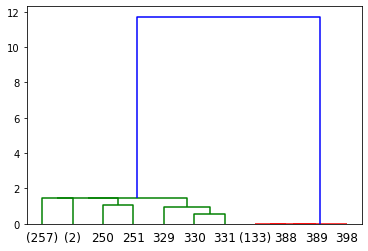

number time clusters:  2


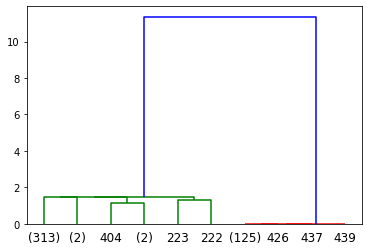

number time clusters:  2


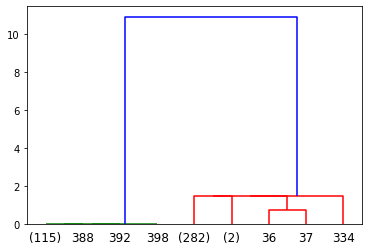

number time clusters:  2


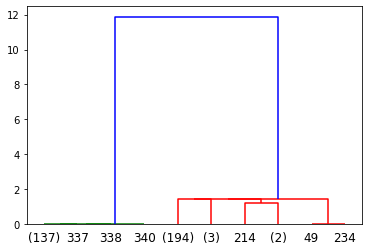

number time clusters:  2


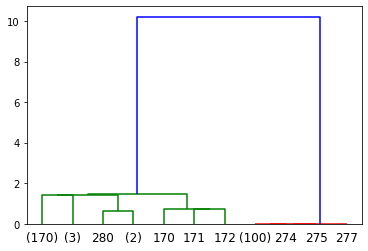

number time clusters:  2


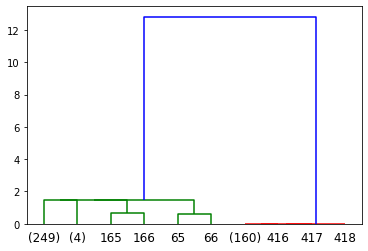

number time clusters:  2


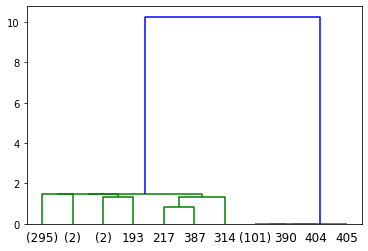

number time clusters:  2


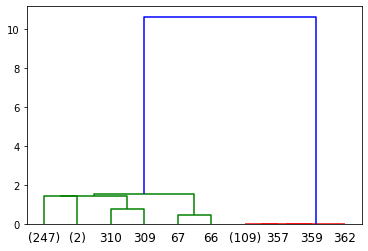

number time clusters:  2


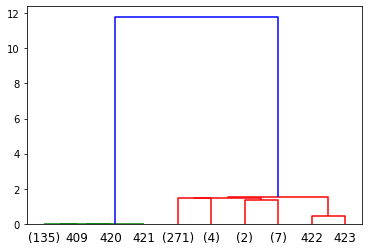

number time clusters:  2
Jacc


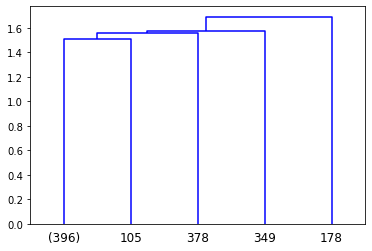

number time clusters:  1


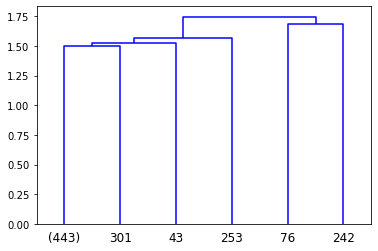

number time clusters:  1


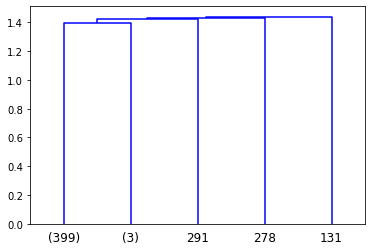

number time clusters:  1


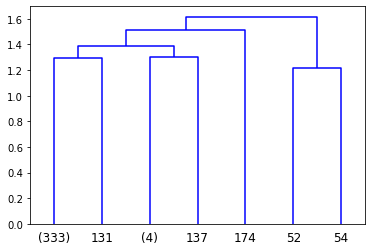

number time clusters:  1


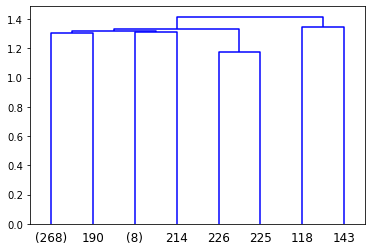

number time clusters:  1


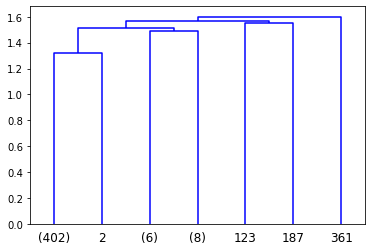

number time clusters:  1


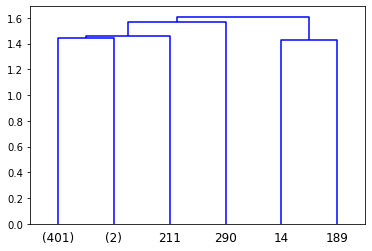

number time clusters:  1


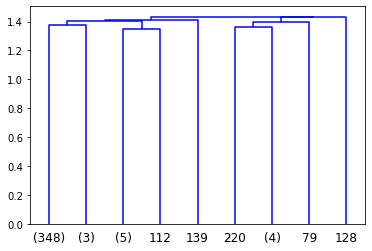

number time clusters:  1


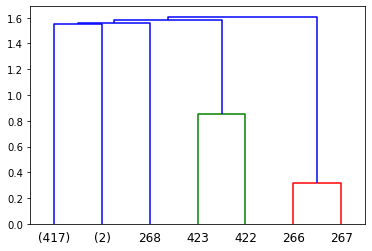

number time clusters:  1


In [47]:
for s in range(1,10):
    file_aux = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold11.0_fmri_dsk.npy')
    file = np.ones((len(file_aux),len(file_aux))) - file_aux
    
    clustering_fmri = findCommunitiesHierarchicalSingleLinkage(file)

    print("number time clusters: ", len(np.unique(clustering_fmri)))

print("Jacc")
for s in range(1,10):
    file_aux = np.load('/strombolihome/fribeiro/Thesis_project/Results/Jacc_giant_component/time_points/subj0' + str(s) + '/Jaccard_Index_giant_component_threshold11.0_fmri_dsk.npy')
    file = np.ones((len(file_aux),len(file_aux))) - file_aux
    
    clustering_fmri = findCommunitiesHierarchicalSingleLinkage(file)

    print("number time clusters: ", len(np.unique(clustering_fmri)))

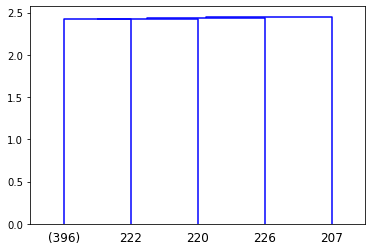

number time clusters:  269


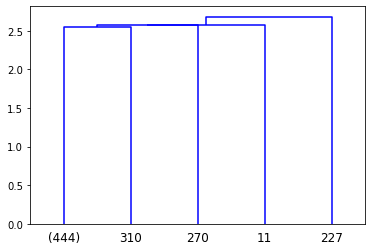

number time clusters:  335


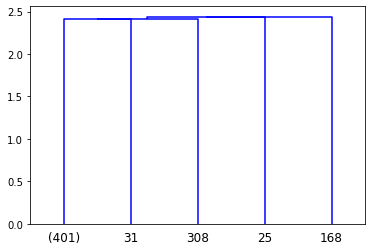

number time clusters:  254


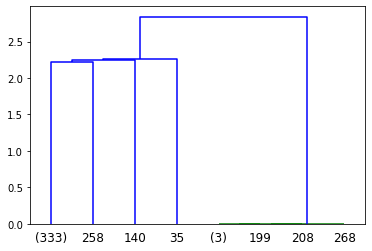

number time clusters:  133


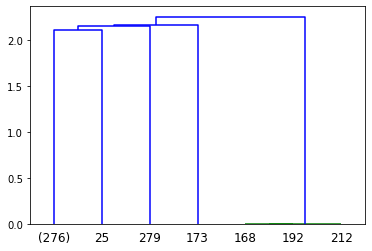

number time clusters:  45


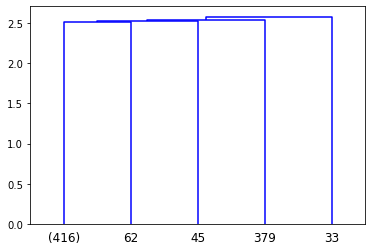

number time clusters:  272


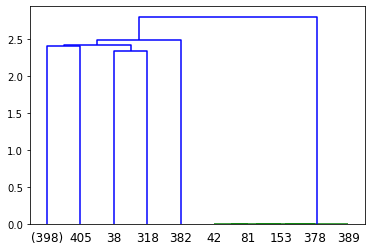

number time clusters:  285


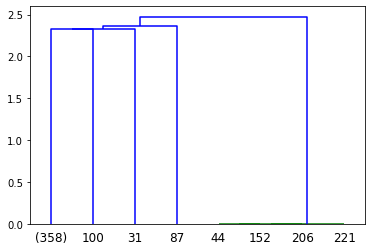

number time clusters:  197


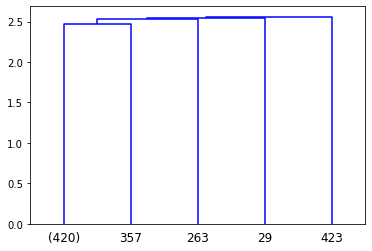

number time clusters:  319
Jacc


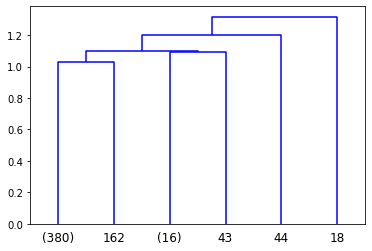

number time clusters:  1


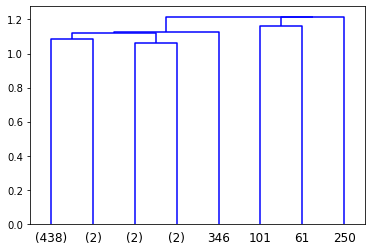

number time clusters:  1


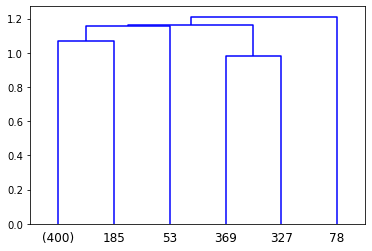

number time clusters:  1


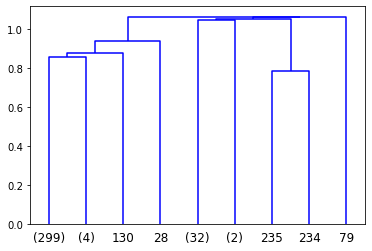

number time clusters:  1


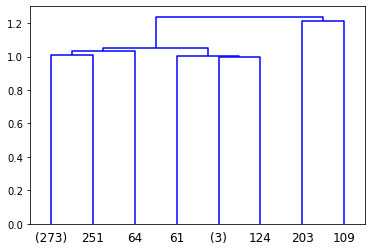

number time clusters:  1


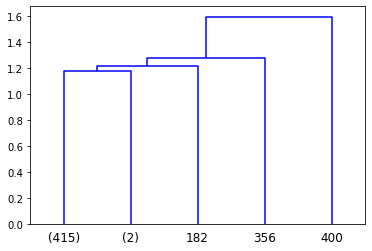

number time clusters:  1


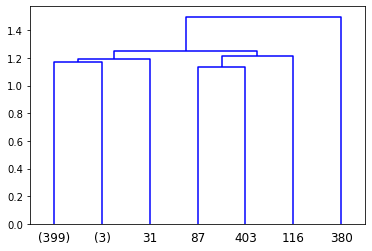

number time clusters:  1


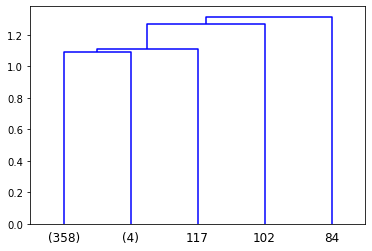

number time clusters:  1


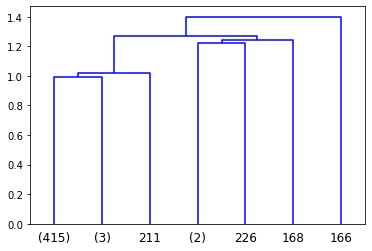

number time clusters:  1


In [48]:
for s in range(1,10):
    file_aux = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold7.000000000000001_eeg_alpha_dsk.npy')
    file = np.ones((len(file_aux),len(file_aux))) - file_aux
    clustering_eeg_alpha = findCommunitiesHierarchicalSingleLinkage(file)

    print("number time clusters: ", len(np.unique(clustering_eeg_alpha)))
    
print("Jacc")
for s in range(1,10):
    file_aux = np.load('/strombolihome/fribeiro/Thesis_project/Results/Jacc_giant_component/time_points/subj0' + str(s) + '/Jaccard_Index_giant_component_threshold7.000000000000001_eeg_alpha_dsk.npy')
    file = np.ones((len(file_aux),len(file_aux))) - file_aux
    clustering_eeg_alpha = findCommunitiesHierarchicalSingleLinkage(file)

    print("number time clusters: ", len(np.unique(clustering_eeg_alpha)))

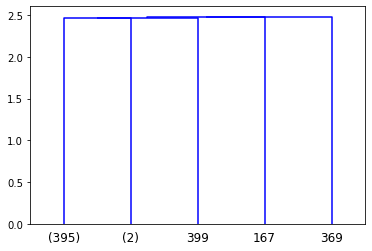

number time clusters:  301


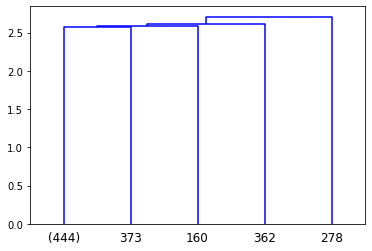

number time clusters:  385


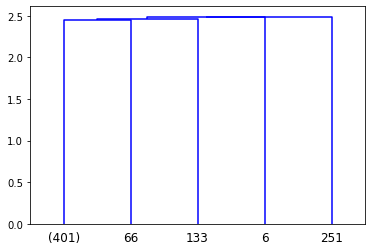

number time clusters:  345


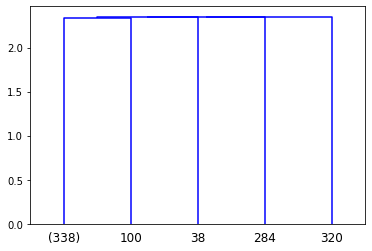

number time clusters:  189


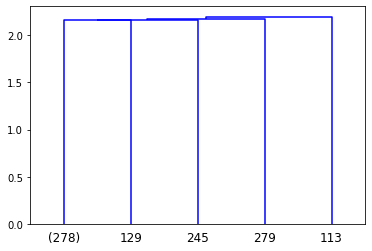

number time clusters:  46


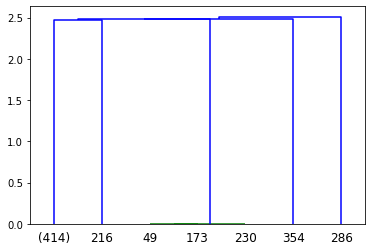

number time clusters:  353


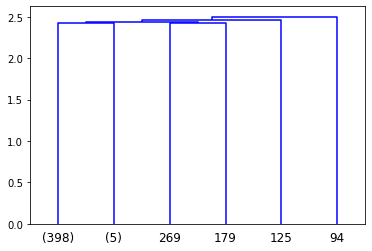

number time clusters:  332


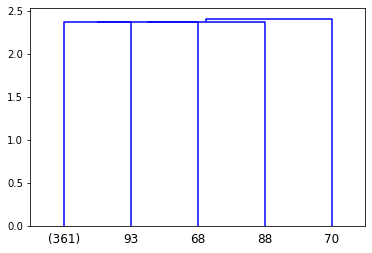

number time clusters:  225


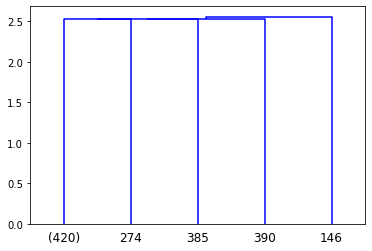

number time clusters:  355


In [29]:
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold6.1_eeg_beta_dsk.npy')
    
    clustering_eeg_beta = findCommunitiesHierarchicalSingleLinkage(file)

    print("number time clusters: ", len(np.unique(clustering_eeg_beta)))

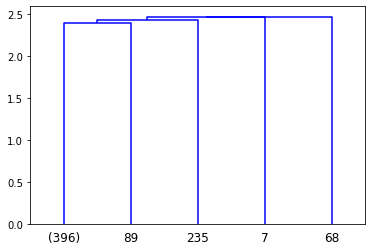

number time clusters:  302


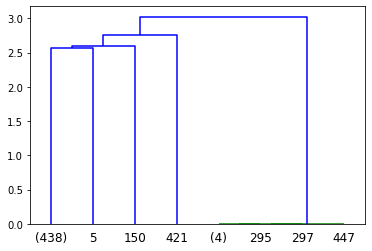

number time clusters:  348


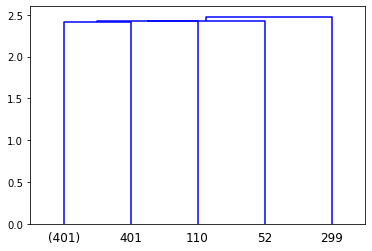

number time clusters:  294


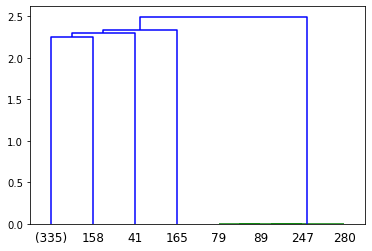

number time clusters:  209


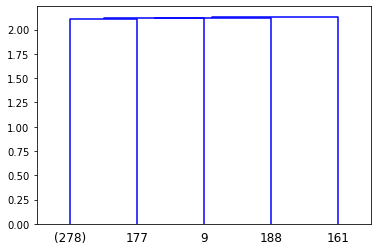

number time clusters:  36


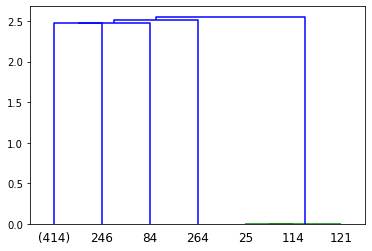

number time clusters:  310


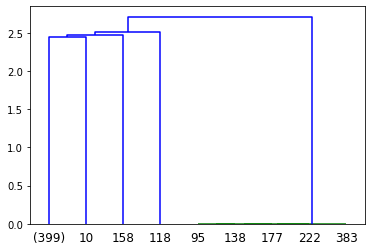

number time clusters:  297


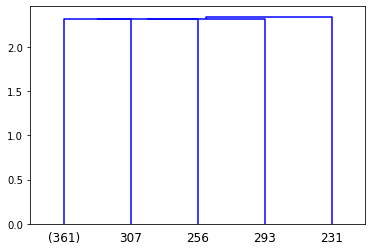

number time clusters:  226


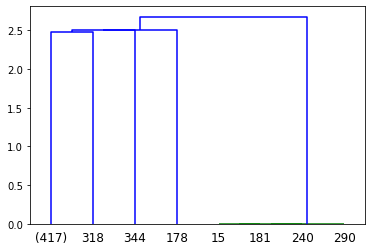

number time clusters:  331


In [30]:
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold7.5_eeg_delta_dsk.npy')
    
    clustering_eeg_delta = findCommunitiesHierarchicalSingleLinkage(file)

    print("number time clusters: ", len(np.unique(clustering_eeg_delta)))

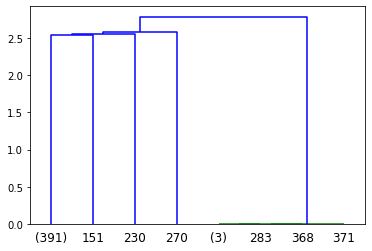

number time clusters:  299


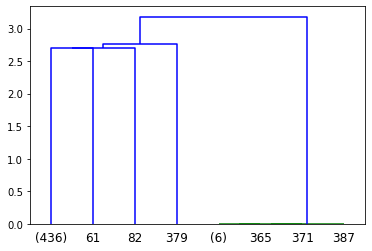

number time clusters:  311


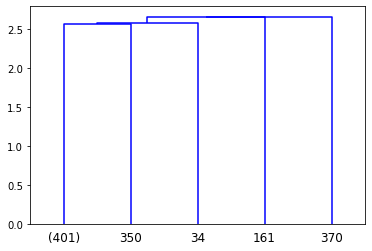

number time clusters:  335


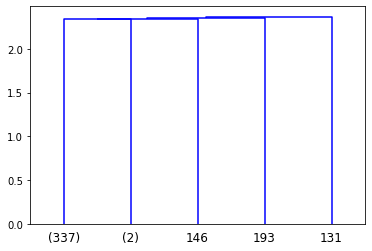

number time clusters:  208


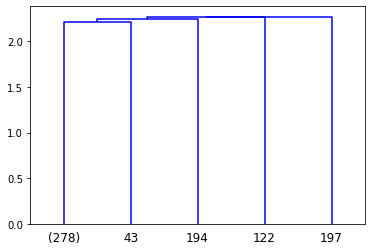

number time clusters:  55


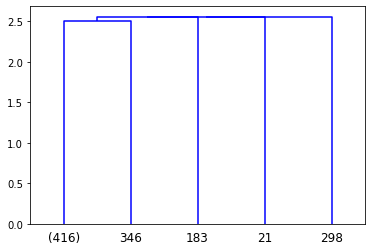

number time clusters:  314


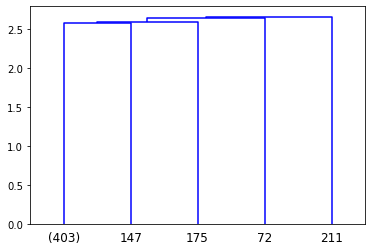

number time clusters:  240


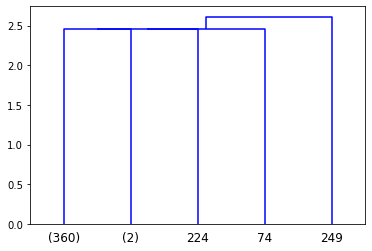

number time clusters:  211


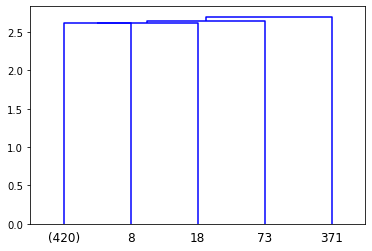

number time clusters:  324


In [31]:
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold7.000000000000001_eeg_gamma_dsk.npy')
    clustering_eeg_gamma = findCommunitiesHierarchicalSingleLinkage(file)

    print("number time clusters: ", len(np.unique(clustering_eeg_gamma)))

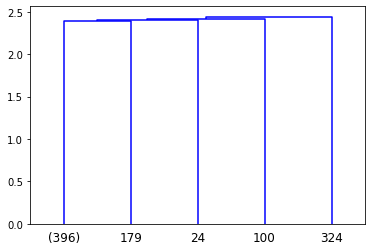

number time clusters:  313


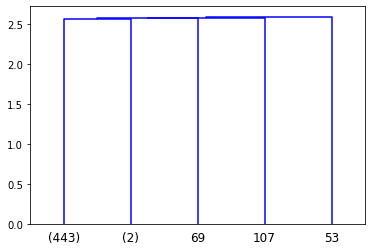

number time clusters:  382


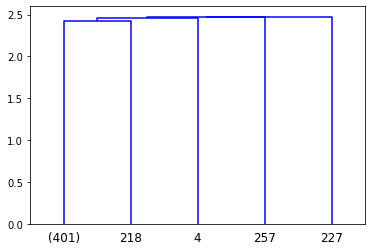

number time clusters:  323


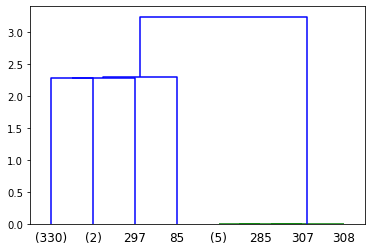

number time clusters:  176


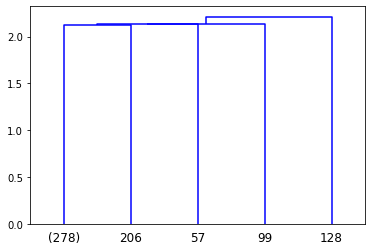

number time clusters:  61


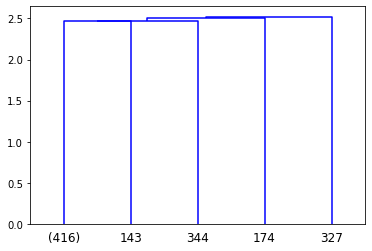

number time clusters:  335


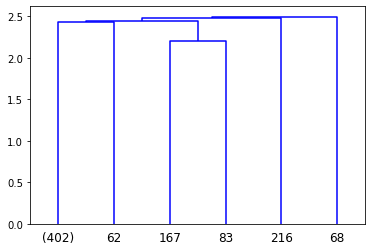

number time clusters:  319


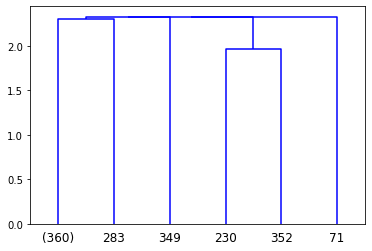

number time clusters:  242


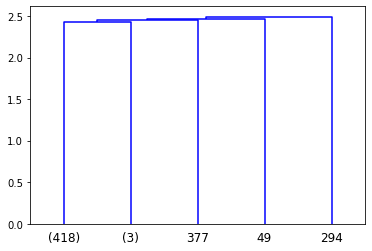

number time clusters:  328


In [32]:
for s in range(1,10):
    file = np.load('/strombolihome/fribeiro/Thesis_project/Results/NMI_connected_components/time_points/subj0' + str(s) + '/NMI_components_' + str(s) + '_threshold6.6000000000000005_eeg_theta_dsk.npy')
    
    clustering_eeg_theta = findCommunitiesHierarchicalSingleLinkage(file)

    print("number time clusters: ", len(np.unique(clustering_eeg_theta)))

In [91]:
intersection_fmri = np.intersect1d(np.nonzeros(clustering_fmri), communities_fmri[1])
print(intersection_fmri)

intersection_eeg_alpha = np.intersect1d(clustering_eeg_alpha, communities_eeg_alpha[1])
print(intersection_eeg_alpha)

[  6  11  13  15  16  17  18  19  31  33  37  39  41  42  43  45  46  49
  50  51  54  56  58  59  60  62  63  64  65  66  69  70  71  73  75  76
  79  81  83  84  87  89  90  91  94  98 111 112 115 116 120 121 122 123
 128 141 144 146 148 149 151 157 158 164 165 166 167 170 172 173 177 180
 181 183 184 186 190 197 198 211 213 214 215 217 220 222 231 232 239 243
 244 249 252 253 254 257 262 263 265 266 267 268 269 270 287 288 290 292
 293 303 308 310 318 320 343 347 348 351 353 358 359 361 364 365 366 369
 370 371 373 381 382 383 386 388 389 398]
[]


In [92]:
# to check the number of components for the these time points - only 1 component (fully connected)

def comparisonNumberComponents(file, time_points, type_data, atlas, threshold):
    
    G_array = createArrayGraph(file, type_data)
    num_components = np.zeros(len(time_points))
    
    n=0
    for t in time_points:
        #print(t)
            
        graph_components = getThresholdComponents(G_array[t],threshold,type_data, 'percentage')
        num_components[n] = len(graph_components) #save number of components for each time point
        n += 1
        
    print(num_components)

comparisonNumberComponents(dir_fmri_desikan + 'subj01-7T/conn_desi_phase_coh_time_fmri.mat', intersection_fmri, 'fmri', 'dsk', 0.11)
comparisonNumberComponents(dir_eeg_desikan + 'subj01-7T/conn_desi_cohi_time_eeg_alpha_correct_subj1-7T_.mat', intersection_eeg_alpha, 'eeg_alpha', 'dsk', 0.07)

threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.         -0.98976446
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
  -0.99964343]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.         -0.98976446  0.         ...  0.          0.
   0.        ]
 [ 0.          0.         -0.99964343 ...  0.          0.
   0.        ]]
threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
  -0.99436368]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.         -0.99436368 ...  0.          0.
   0.        ]]
threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 

threshold
[[ 0.         -0.99169997  0.         ...  0.          0.
   0.        ]
 [-0.99169997  0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ... -0.99883016  0.
   0.        ]
 ...
 [ 0.          0.         -0.99883016 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
threshold
[[ 0.         -0.99436252  0.         ...  0.          0.
   0.        ]
 [-0.99436252  0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ... -0.99747735  0.
   0.        ]
 ...
 [ 0.          0.         -0.99747735 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
threshold
[[ 0.         -0.9942911   0.         ...  0.          0.
   0.        ]
 [-0.9942

threshold
[[ 0.         -0.99797111  0.         ...  0.         -0.98867211
  -0.99747051]
 [-0.99797111  0.          0.         ...  0.          0.99622228
   0.9999724 ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.98867211  0.99622228  0.         ...  0.          0.
   0.99684   ]
 [-0.99747051  0.9999724   0.         ...  0.          0.99684
   0.        ]]
threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.         -0.99835191
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.99980811]
 [ 0.          0.         -0.99835191 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.99980811  0.
   0.        ]]
threshold
[[ 0.          0.          0.         ... -0.9884686 

threshold
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.99206404]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.99206404 0.         ... 0.         0.         0.        ]]
threshold
[[0.         0.99840255 0.         ... 0.         0.         0.        ]
 [0.99840255 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]


threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.99690458 0.99690053]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.99690458 0.         ... 0.         0.         1.        ]
 [0.         0.99690053 0.         ... 0.         1.         0.        ]]
threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.98884803 0.99981753]
 [0.         0.         0.         ... 0.98431445 0.         0.        ]
 ...
 [0.         0.         0.98431445 ... 0.         0.         0.        ]
 [0.         0.98884803 0.         ... 0.         0.         0.98582272]
 [0.         0.99981753 0.         ... 0.         0.98582272 0.        ]]
threshold
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.     

threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ... -0.99132896  0.
   0.        ]
 ...
 [ 0.          0.         -0.99132896 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
threshold
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ... -0.99966007 -0.99828117
   0.        ]
 ...
 [ 0.          0.         -0.99966007 ...  0.          0.99641385
   0.        ]
 [ 0.          0.         -0.99828117 ...  0.99641385  0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]
threshold
[[ 0.         -0.99057083  0.         ...  0.          0.
   0.   

[]


In [102]:
# to compare communities for time points with similar set of components - fully connected graph but completely different communities

from community import community_louvain
from igraph import *

def communityFindingLouvain(G, atlas):
    
    if atlas == 'dsk':
        num_regions = 68
    else:
        num_regions = 148
    
    part = community_louvain.best_partition(G) #returns dictionary assign a community (integer) to each node
    mod = community_louvain.modularity(part, G) #compute modularity
    #print("Modularity: ", mod)
        
    #creates a list with the community number for each node in the order that appears in G.nodes()
    communities = [part.get(node) for node in G.nodes()] 
        
    #determine number of nodes in each community
    num_communities = max(communities)+1
    count_communities = np.zeros((num_communities,), dtype=int)
    content_communities = np.zeros(num_regions)
    for key,value in part.items():
        count_communities[value] += 1
        content_communities[key] = int(value) #store for node (key) the community label (value)
    
    return  mod, num_communities, content_communities  

def comparisonCommunities(file, time_points, type_data, atlas, threshold):
    
    G_array = createArrayGraph(file, type_data)
    num_time_points = len(time_points)
    
    num_communities = np.zeros(num_time_points)
    
    nmi = np.zeros((num_time_points, num_time_points)) #comparison between all time points component distribution
    np.fill_diagonal(nmi, 1) #fill the diagonal as NMI will be 1
    
    communities = np.empty(num_time_points, dtype=object)
    
    n=0
    for t in time_points:
        
        if type_data == 'fmri':
            G, conn_matrix, min_pos, max_neg = thresholdGraph(G_array[t], threshold, type_data, 'percentage')
        else:
            G, conn_matrix, min_coh = thresholdGraph(G_array[t], threshold, type_data, 'percentage')
            
        giant_component = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        conn_matrix = nx.to_numpy_matrix(giant_component)
        #conversion to binary undirected graph
        conn_matrix = bct.utils.binarize(conn_matrix)
        # Best partition according to Louvain algorithm for original network
        G = nx.from_numpy_matrix(conn_matrix)
        
        modularity, num_communities[n], communities[n] = communityFindingLouvain(G, 'dsk')
        n += 1
    
    #print(communities)
    
    #compute nmi between each time point communities
    for n in range(num_time_points):
        for m in range(1,num_time_points):
            
            nmi[n,m] = compare_communities(communities[n], communities[m], method='nmi')
            nmi[m,n] = nmi[n,m] #matrix is symmetrical
    
    np.fill_diagonal(nmi, 0) #fill the diagonal as NMI will be 1
    print(nmi)
    
    f = plt.figure(figsize=(20, 20))
    plt.matshow(nmi, fignum=f.number)
    plt.xticks(fontsize=14, rotation=45)
    plt.yticks(fontsize=14)
    cb = plt.colorbar()
    cb.ax.tick_params(labelsize=14)
    
    plt.show()



[[0.         0.14016278 0.10104887 ... 0.13378739 0.10732124 0.08500785]
 [0.14016278 0.         0.3405305  ... 0.11916899 0.1136568  0.14182867]
 [0.10104887 0.3405305  0.         ... 0.16940064 0.12467952 0.12746405]
 ...
 [0.13378739 0.11916899 0.16940064 ... 0.         0.47901759 0.08585079]
 [0.10732124 0.1136568  0.12467952 ... 0.47901759 0.         0.10325911]
 [0.08500785 0.14182867 0.12746405 ... 0.08585079 0.10325911 0.        ]]


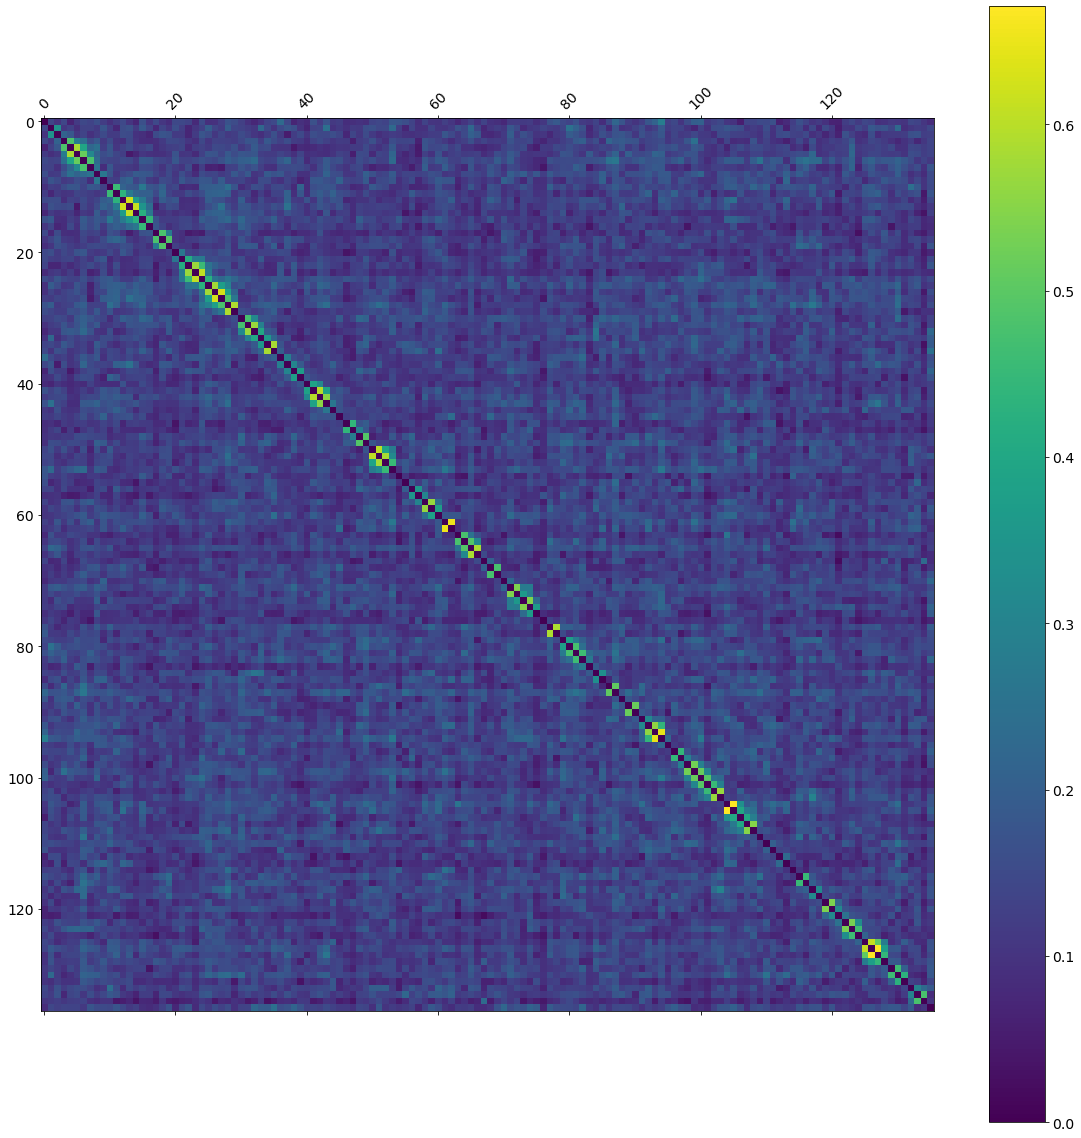

In [103]:
comparisonCommunities(dir_fmri_desikan + 'subj01-7T/conn_desi_phase_coh_time_fmri.mat', intersection_fmri, 'fmri', 'dsk', 0.11)
#comparisonCommunities(dir_eeg_desikan + 'subj01-7T/conn_desi_cohi_time_eeg_alpha_correct_subj1-7T_.mat', intersection_eeg_alpha, 'eeg_alpha', 'dsk', 0.07)

[[0.         0.24776585 0.1786127  ... 0.10358317 0.07575212 0.23821689]
 [0.24776585 0.         0.1387479  ... 0.12439452 0.15656266 0.12333486]
 [0.1786127  0.1387479  0.         ... 0.21063743 0.10847812 0.15095999]
 ...
 [0.10358317 0.12439452 0.21063743 ... 0.         0.08300467 0.11880713]
 [0.07575212 0.15656266 0.10847812 ... 0.08300467 0.         0.09951195]
 [0.23821689 0.12333486 0.15095999 ... 0.11880713 0.09951195 0.        ]]


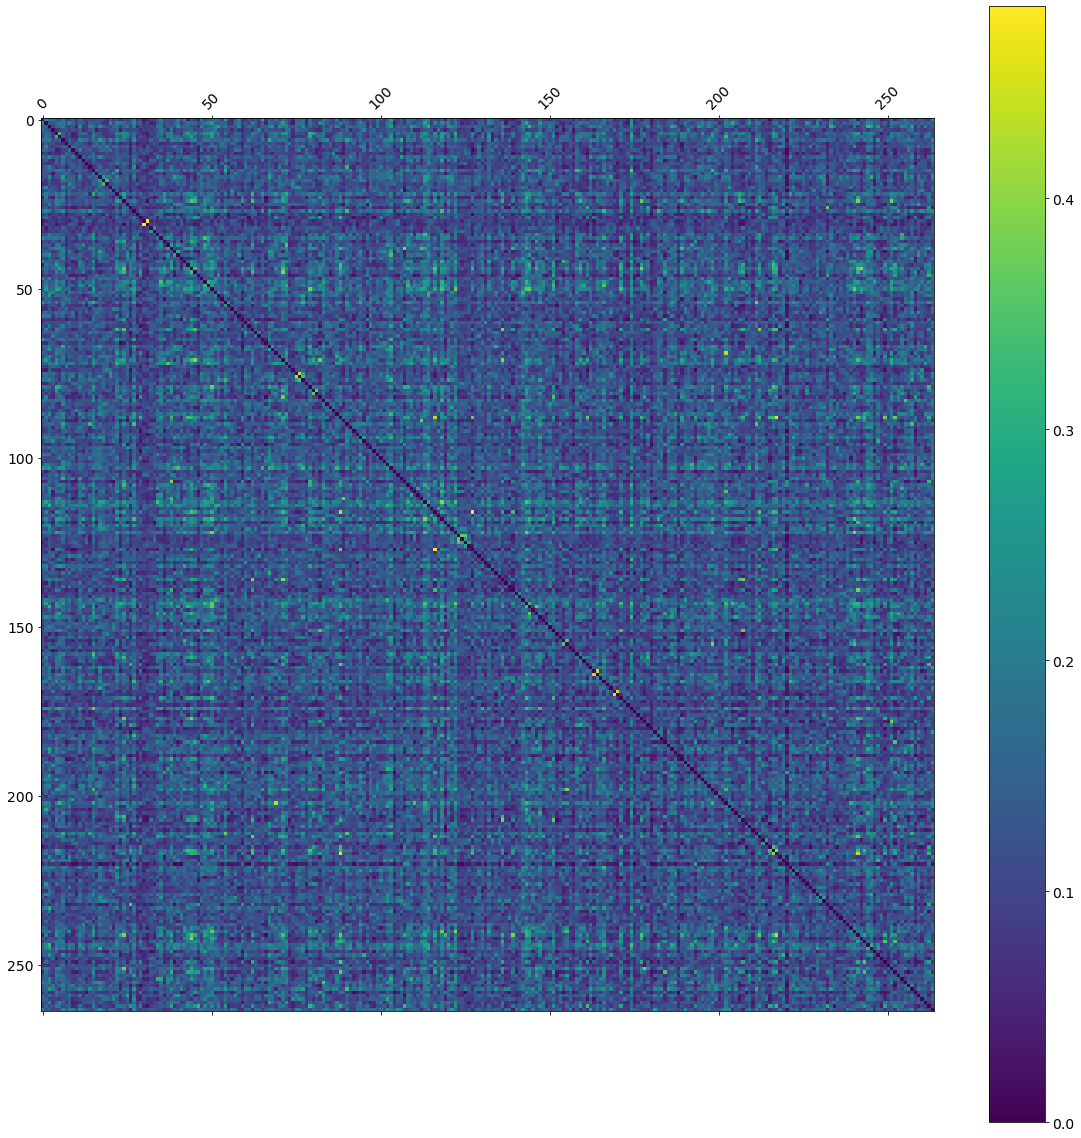

In [104]:
comparisonCommunities(dir_fmri_desikan + 'subj01-7T/conn_desi_phase_coh_time_fmri.mat', communities_fmri[0], 'fmri', 'dsk', 0.11)
